In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR

In this file, we do two things:

- plot the price & volume of the cleaned "continuous front contract"

- construct the pnl curve of the agent trading rule

Code will not modify any files.

# **Price & Volume of the continuous front contract**

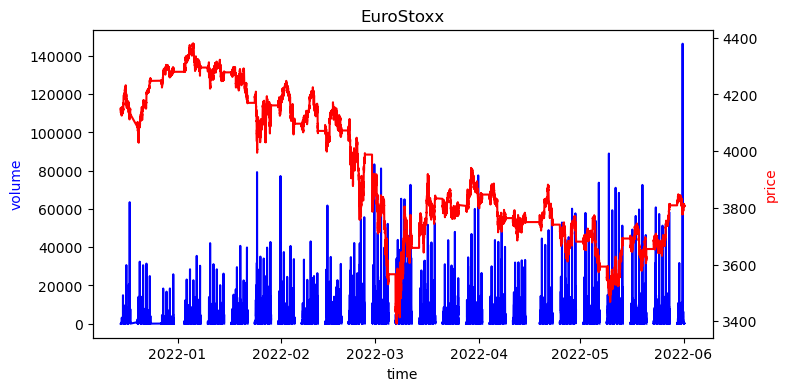

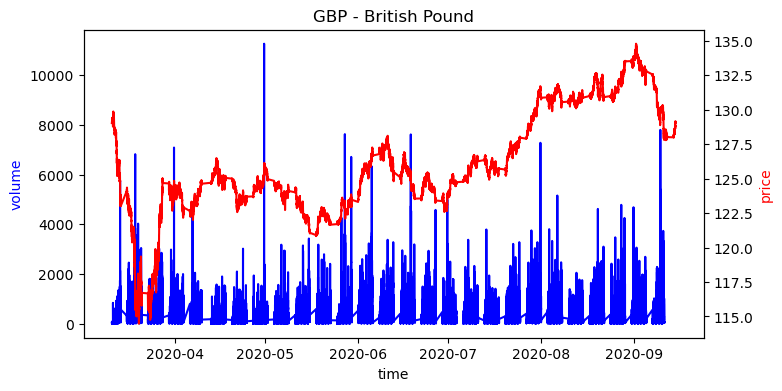

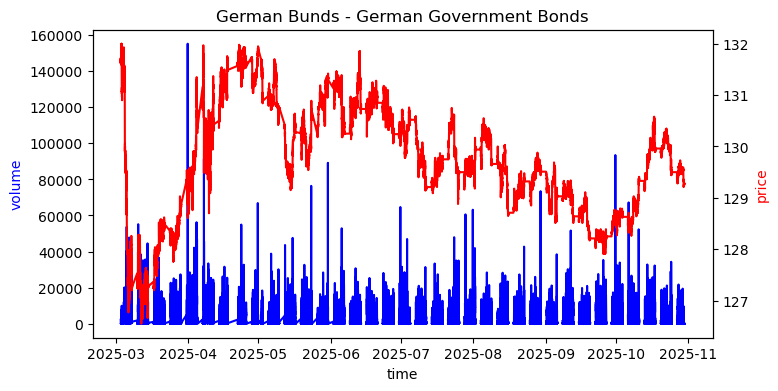

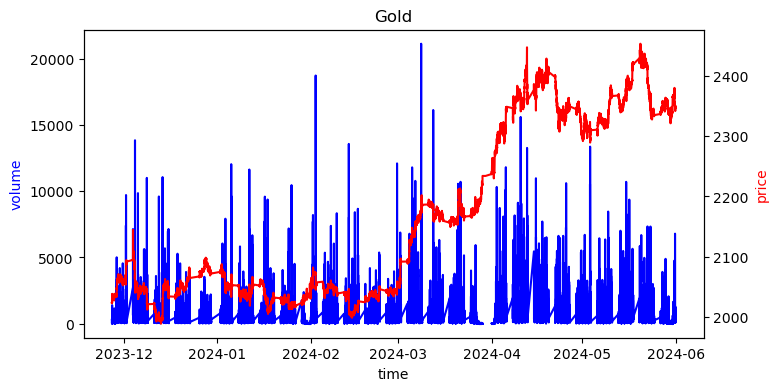

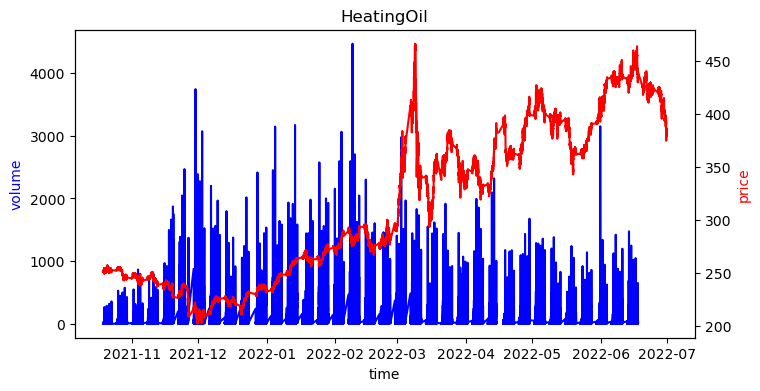

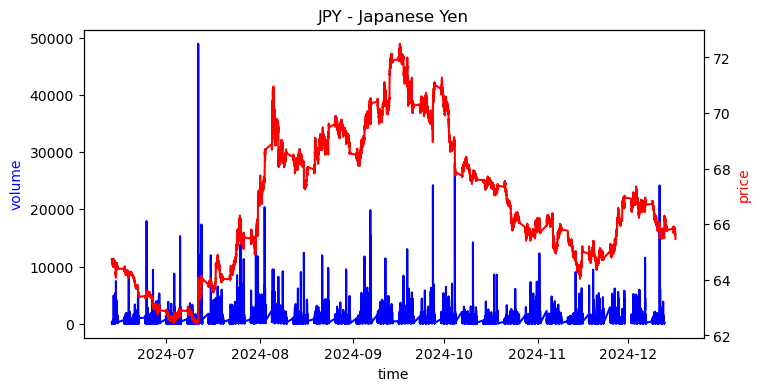

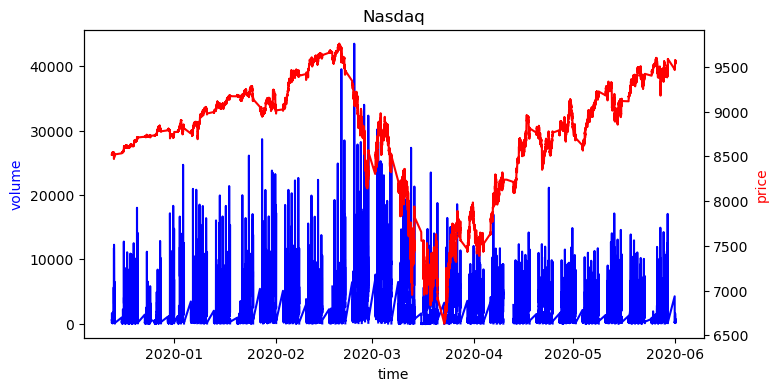

In [2]:
raw_data_path=RAW_DATA_DIR
data_path=DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

for market in markets:
    
    futures_path=data_path/'futures_right'/'minute_5'
    data_prep=pd.read_parquet(futures_path/f'{market}_prep.parquet')
    data_trading=pd.read_parquet(futures_path/f'{market}.parquet')
    data=pd.concat([data_prep,data_trading],axis=0)
    data=data.drop_duplicates('time',keep='last').sort_values('time').reset_index(drop=True)
    
    fig,ax=plt.subplots(figsize=(8,4))
    ax.plot(data['time'],data['volume'],color='blue')
    ax.set_xlabel('time')
    ax.set_ylabel('volume',color='blue')
    ax2=ax.twinx()
    ax2.plot(data['time'],data['close'],color='red')
    ax2.set_ylabel('price',color='red')
    plt.title(f'{market}')
    plt.show()

# **Construct PnL Curves**

Let's assume at time $t$, the price is $p_t$, the trading volume is $\Delta q_t$, the net position is $q_t$.

Then the cash flow at time $t$ is
$$
\Delta \text{Cash}_t = - p_t \Delta q_t 
$$

- if $\Delta q_t>0$, we spend cash to buy shares

- if $\Delta q_t>0$, we sell shares and get cash

The cumulative cash at time $t$ is
$$
\text{Cumulative Cash}_t = \text{Cumulative Cash}_{t-1} + \Delta \text{Cash}_t= \text{Cumulative Cash}_{t-1} - p_t \Delta q_t 
$$

The market value of the net position at time $t$ is
$$
\text{Market Value of Inventory} = p_t q_t
$$

The PnL at time $t$ is:
$$
\text{PnL}_t = \text{Cumulative Cash}_t + p_t q_t
$$

========== EuroStoxx ==========
            count  mean   std  min  25%  50%  75%  max
position  29603.0  2.09  1.83 -3.0  1.0  2.0  3.0  6.0
trade     29603.0  0.00  0.15 -5.0  0.0  0.0  0.0  3.0


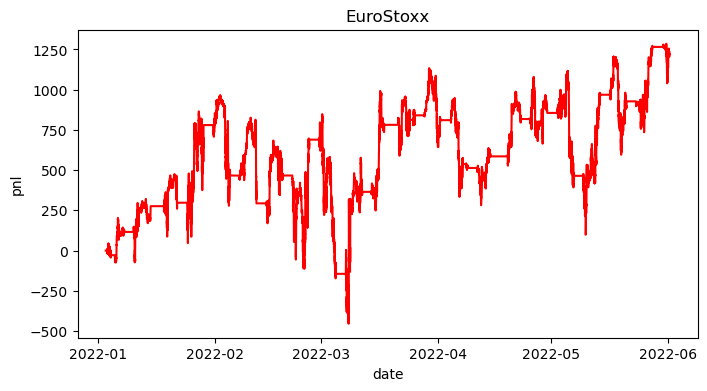

========== GBP - British Pound ==========
            count  mean   std   min  25%  50%  75%   max
position  20549.0 -2.44  5.42 -17.0 -5.0 -2.0  0.0  17.0
trade     20549.0  0.00  0.99 -21.0  0.0  0.0  0.0  29.0


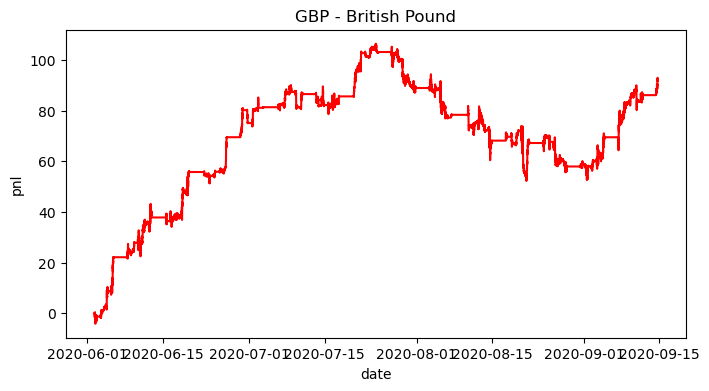

========== German Bunds - German Government Bonds ==========
            count  mean   std   min  25%  50%  75%   max
position  29808.0  2.58  3.74 -12.0  0.0  2.0  5.0  23.0
trade     29808.0  0.00  0.54 -12.0  0.0  0.0  0.0  11.0


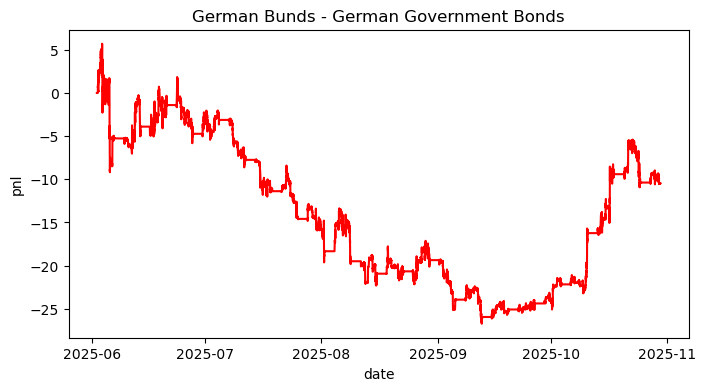

========== Gold ==========
            count  mean   std  min  25%  50%  75%  max
position  30013.0   1.5  2.70 -7.0  0.0  1.0  3.0  8.0
trade     30013.0   0.0  0.45 -7.0  0.0  0.0  0.0  6.0


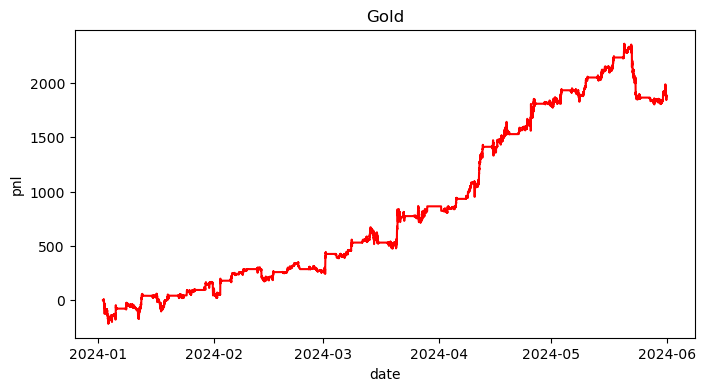

========== HeatingOil ==========
            count  mean   std  min  25%  50%  75%  max
position  23911.0  1.33  1.96 -4.0  0.0  1.0  2.0  6.0
trade     23911.0 -0.00  0.25 -5.0  0.0  0.0  0.0  7.0


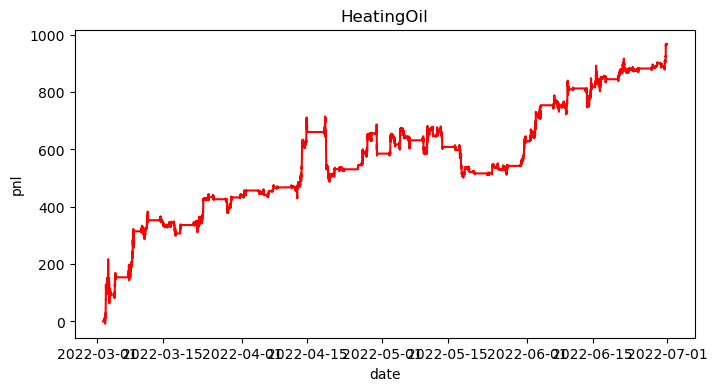

========== JPY - Japanese Yen ==========
            count  mean   std   min  25%  50%  75%  max
position  20825.0 -2.22  3.00 -10.0 -5.0 -1.0  0.0  8.0
trade     20825.0  0.00  0.65 -10.0  0.0  0.0  0.0  9.0


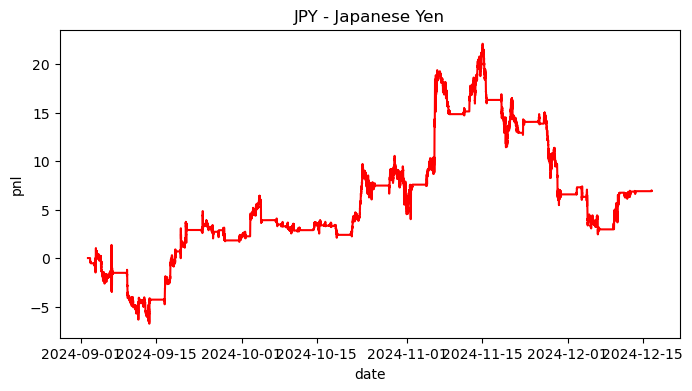

========== Nasdaq ==========
            count  mean   std   min  25%  50%  75%   max
position  29532.0  3.95  3.68 -11.0  0.0  4.0  7.0  11.0
trade     29532.0  0.00  1.15 -16.0  0.0  0.0  0.0  17.0


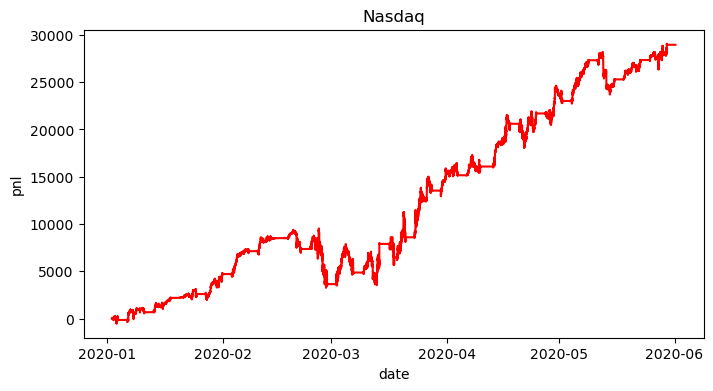

In [3]:
def show_agent_pnl(
    data_path:Path,
)->None:
    
    files=sorted([p.name for p in data_path.glob("*.parquet")])
    markets=[f[:-8] for f in files]

    for market in markets:
        print(f'========== {market} ==========')
        data=pd.read_parquet(data_path/f'{market}.parquet')
        data['position']=data['position'].ffill()
        data['trade']=data['position'].diff().fillna(0)
        print(data[['position','trade']].describe().round(2).T)
        
        data['cash']=-data['trade']*data['price']
        data['inventory']=data['position']*data['price']
        data['PNL']=data['cash'].cumsum()+data['inventory']

        plt.figure(figsize=(8,4))
        plt.plot(data['time'],data['PNL'],color='red')
        plt.xlabel('date')
        plt.ylabel('pnl')
        plt.title(market)
        plt.show()

       
data_path=DATA_DIR/'agent_right'
show_agent_pnl(data_path)